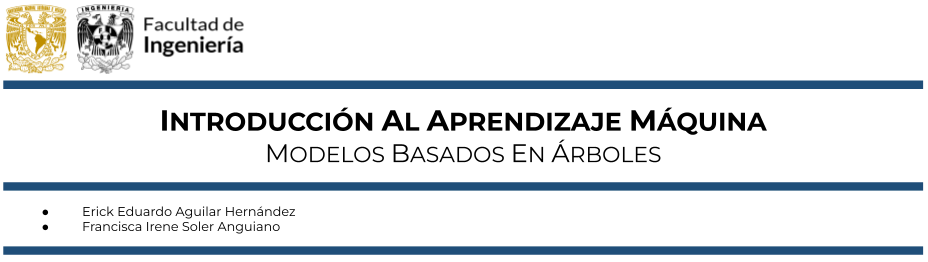

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 5.3 — Implementación: Ajuste de un árbol de clasificación
___

### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para reproducir el ajuste de un árbol de clasificación. 
Se cargan herramientas para manipulación de datos, visualización, lectura de archivos locales y construcción del modelo con `scikit-learn`. 
También se fija el estilo gráfico `ggplot`, de modo que las tablas y visualizaciones mantengan una presentación homogénea a lo largo del notebook.


In [1]:
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

### Carga del conjunto German Credit

Se carga el conjunto **German Credit**, utilizado para ilustrar un problema de clasificación binaria asociado al riesgo crediticio. 
La variable objetivo `class` distingue entre créditos clasificados como `good` y `bad`. 
La transposición de las primeras observaciones permite inspeccionar con mayor comodidad los nombres de las variables y los tipos de valores presentes en el conjunto.


In [2]:
data_paths = [Path("datos") / "credit-g.csv", Path("..") / "datos" / "credit-g.csv"]
data_path = next(path for path in data_paths if path.exists())
credit_df = pd.read_csv(data_path)
credit_df.head(5).transpose()


,0,1,2,3,4
checking_status,<0,0<=X<200,no checking,<0,<0
duration,6,48,12,42,24
credit_history,critical/other existing credit,existing paid,critical/other existing credit,existing paid,delayed previously
purpose,radio/tv,radio/tv,education,furniture/equipment,new car
credit_amount,1169,5951,2096,7882,4870
savings_status,no known savings,<100,<100,<100,<100
employment,>=7,1<=X<4,4<=X<7,4<=X<7,1<=X<4
installment_commitment,4,2,2,2,3
personal_status,male single,female div/dep/mar,male single,male single,male single
other_parties,none,none,none,guarantor,none


### Selección de variables predictoras y variable objetivo

Se selecciona un subconjunto de variables numéricas y categóricas que describen características del crédito y del solicitante. 
A diferencia del caso de regresión, aquí la respuesta no es continua: el objetivo es aprender reglas de decisión que separen las observaciones en clases. 
El DataFrame `data_df` conserva únicamente las covariables seleccionadas y la columna `class`, dejando listo el conjunto para la exploración y el preprocesamiento.


In [3]:
features = [
    "duration",
    "credit_amount",
    "age",
    "checking_status",
    "employment",
    "housing",
    "purpose",
    "installment_commitment",
    "existing_credits",
    "job",
    "num_dependents"
]
data_df = credit_df[features+["class"]]
display(data_df)

,duration,credit_amount,age,checking_status,employment,housing,purpose,installment_commitment,existing_credits,job,num_dependents,class
0,6,1169,67,<0,>=7,own,radio/tv,4,2,skilled,1,good
1,48,5951,22,0<=X<200,1<=X<4,own,radio/tv,2,1,skilled,1,bad
2,12,2096,49,no checking,4<=X<7,own,education,2,1,unskilled resident,2,good
3,42,7882,45,<0,4<=X<7,for free,furniture/equipment,2,1,skilled,2,good
4,24,4870,53,<0,1<=X<4,for free,new car,3,2,skilled,2,bad
...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,31,no checking,4<=X<7,own,furniture/equipment,3,1,unskilled resident,1,good
996,30,3857,40,<0,1<=X<4,own,used car,4,1,high qualif/self emp/mgmt,1,good
997,12,804,38,no checking,>=7,own,radio/tv,4,1,skilled,1,good
998,45,1845,23,<0,1<=X<4,for free,radio/tv,4,1,skilled,1,bad


### Exploración de variables categóricas

Antes de ajustar el árbol, se revisa la relación entre algunas variables categóricas y la clase observada mediante tablas de contingencia. 
Este paso ayuda a identificar categorías con distribuciones distintas de créditos `good` y `bad`, lo que anticipa posibles particiones útiles para el árbol. 
En árboles de clasificación, las particiones buscan reducir la impureza de los nodos, por lo que estas diferencias de composición son especialmente informativas.


In [4]:
categoricals = [
    "checking_status",
    "employment",
    "housing",
    "purpose",
    "job",
]

for col in categoricals:
    display(pd.crosstab(data_df[col], data_df["class"]))

class,bad,good
checking_status,,
0<=X<200,105,164
<0,135,139
>=200,14,49
no checking,46,348


class,bad,good
employment,,
1<=X<4,104,235
4<=X<7,39,135
<1,70,102
>=7,64,189
unemployed,23,39


class,bad,good
housing,,
for free,44,64
own,186,527
rent,70,109


class,bad,good
purpose,,
business,34,63
domestic appliance,4,8
education,22,28
furniture/equipment,58,123
new car,89,145
other,5,7
radio/tv,62,218
repairs,8,14
retraining,1,8


class,bad,good
job,,
high qualif/self emp/mgmt,51,97
skilled,186,444
unemp/unskilled non res,7,15
unskilled resident,56,144


### Codificación de variables categóricas

El árbol de clasificación de `scikit-learn` requiere una matriz numérica de predictores. 
Por ello, las variables categóricas se transforman mediante codificación **one-hot**, creando una columna indicadora por categoría, mientras que las variables numéricas pasan sin modificación. 
Finalmente, la respuesta `class` se convierte a una variable binaria, donde la clase `good` se codifica como 1 y la clase `bad` como 0.


In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Variables categóricas y numéricas
categoricals = [
    "checking_status",
    "employment",
    "housing",
    "purpose"
]

numericals = [
    "duration",
    "credit_amount",
    "age",
    "installment_commitment",
    "existing_credits",
    "num_dependents"
]

# Encoder One Hot
ohe = OneHotEncoder(
    drop=None,           # no elimina categorías
    sparse_output=False, # devuelve DataFrame usable
    handle_unknown="ignore"
)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categoricals),
        ("num", "passthrough", numericals)
    ]
)

# Aplicar transformación
X_transformed = preprocessor.fit_transform(data_df)

# Obtener nombres de columnas
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categoricals)

# Unir nombres
all_features = list(cat_features) + numericals

# Convertir a DataFrame
X = pd.DataFrame(X_transformed, columns=all_features)
y = (data_df["class"] == "good").astype(int)

display(X)
display(y)

,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,checking_status_no checking,employment_1<=X<4,employment_4<=X<7,employment_<1,employment_>=7,employment_unemployed,housing_for free,...,purpose_radio/tv,purpose_repairs,purpose_retraining,purpose_used car,duration,credit_amount,age,installment_commitment,existing_credits,num_dependents
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,1169.0,67.0,4.0,2.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,48.0,5951.0,22.0,2.0,1.0,1.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,2096.0,49.0,2.0,1.0,2.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,42.0,7882.0,45.0,2.0,1.0,2.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,24.0,4870.0,53.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,1736.0,31.0,3.0,1.0,1.0
996,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,30.0,3857.0,40.0,4.0,1.0,1.0
997,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,12.0,804.0,38.0,4.0,1.0,1.0
998,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,45.0,1845.0,23.0,4.0,1.0,1.0


0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: class, Length: 1000, dtype: int64

### Ajuste de un árbol de clasificación

Se divide el conjunto en entrenamiento y prueba para evaluar el modelo sobre observaciones no utilizadas durante el ajuste. 
Después se ajusta un `DecisionTreeClassifier` usando entropía como criterio de partición, de acuerdo con la discusión del libro sobre impureza en clasificación. 
El parámetro `max_depth = 6` controla la complejidad del árbol y la visualización resultante muestra las reglas aprendidas a partir de las variables codificadas.


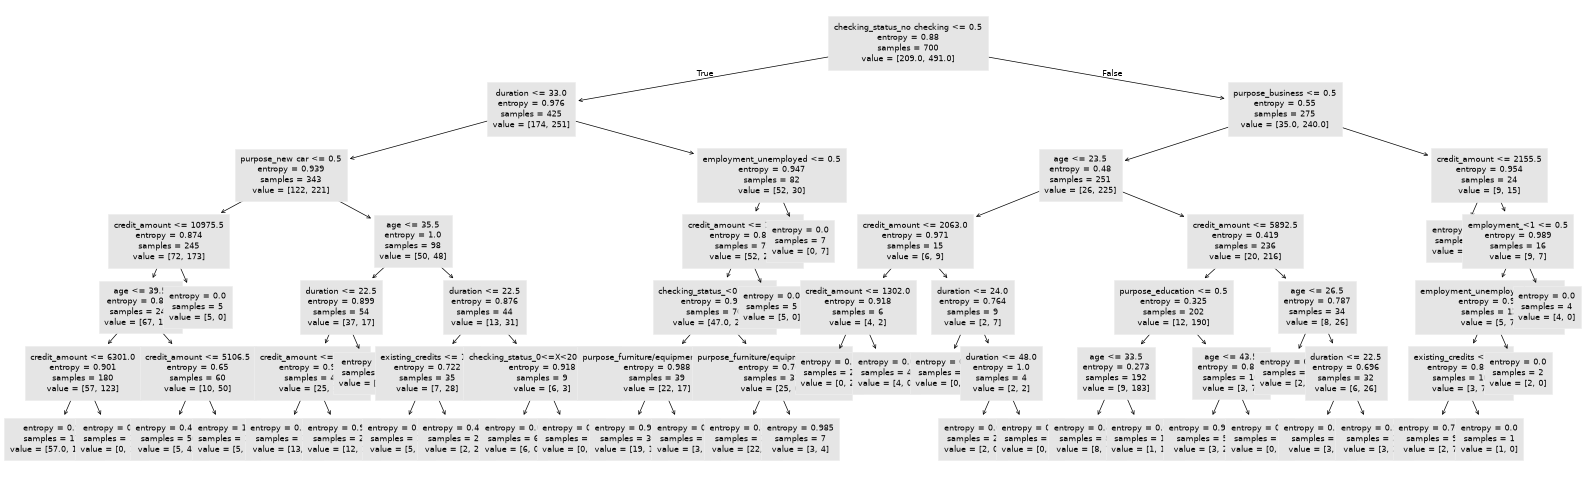

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

#Split de entrenamiento y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

class_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=6,
    random_state=42
).fit(X_train, y_train)


plt.figure(figsize=(20,6))
ars = plot_tree(class_tree,feature_names=all_features, fontsize=6)

____
### Notebook 5.5 — Implementación: Importancia de variables en árboles de clasificación
____

### Importancia de variables en el árbol de clasificación

Una vez ajustado el árbol, se calcula la importancia relativa de cada predictor. 
En clasificación, esta importancia resume la reducción acumulada de impureza atribuible a las particiones donde participa cada variable. 
La tabla y la gráfica ordenan estas contribuciones para identificar qué características tuvieron mayor peso en la construcción de las reglas de decisión del modelo.


,variable,importance
23,credit_amount,0.207617
3,checking_status_no checking,0.206651
22,duration,0.160267
24,age,0.152876
8,employment_unemployed,0.058108
16,purpose_new car,0.041982
0,checking_status_0<=X<200,0.034454
12,purpose_business,0.032408
15,purpose_furniture/equipment,0.032360
26,existing_credits,0.023516


<Axes: xlabel='importance', ylabel='variable'>

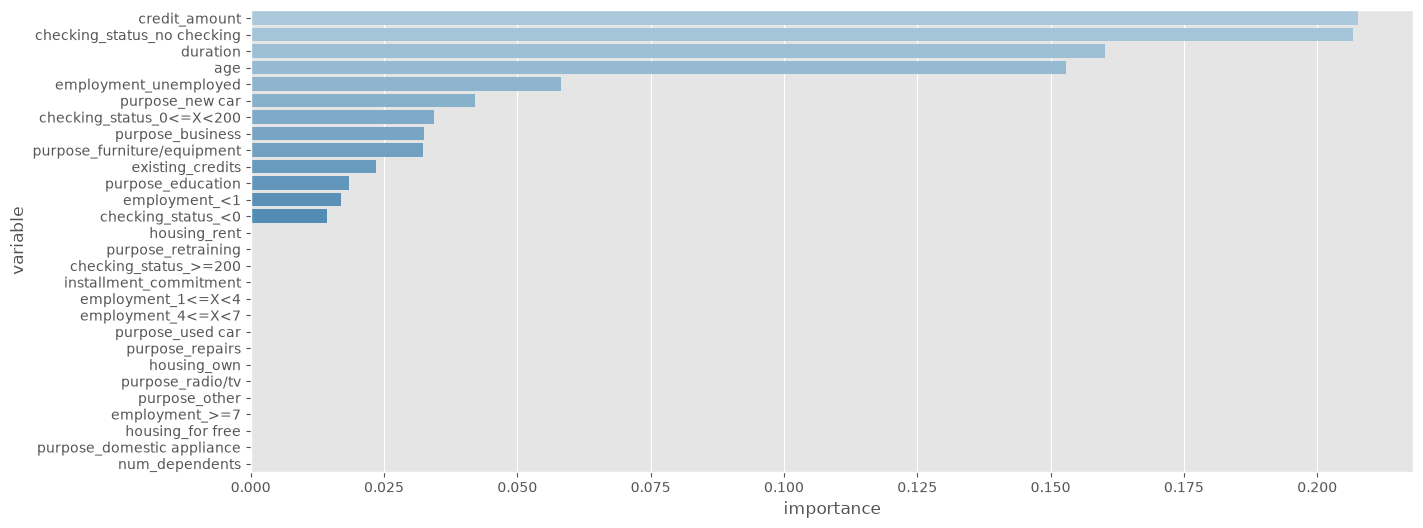

In [7]:
# Importancia
importances = class_tree.feature_importances_

# Crear DataFrame
importances_df = pd.DataFrame({
    "variable": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(importances_df.head(17))
plt.figure(figsize=(15,6))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")